# 05.02 · SVM y el truco del kernel

**Objetivo:** entender las dos ideas que hicieron de las SVM el método dominante justo
antes del deep learning: **el margen máximo** (no vale cualquier frontera, hay una
mejor) y **el truco del kernel** (cómo separar con una curva sin salir de las rectas).

📖 Teoría: [5.1 Modelos clásicos](../../../../../docs/02-deep-learning/05-tipos-de-modelo/5.1-modelos-clasicos.md)

In [1]:
# --- Bootstrap: local o Colab ---------------------------------------------
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/TU_USUARIO/dl-lab.git"

if IN_COLAB:
    subprocess.run(["git", "clone", "-q", REPO_URL, "/content/dl-lab"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "/content/dl-lab"], check=True)
    sys.path.insert(0, "/content/dl-lab/src")

print("Ejecutando en:", "Google Colab" if IN_COLAB else "Local (Docker)")

Ejecutando en: Local (Docker)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs, make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from dllab import set_seed

set_seed(42)

42

## 1. El caso de uso

Una fábrica de rodamientos mide dos cosas de cada pieza que sale de la línea:
**vibración** y **temperatura**. Con eso hay que decidir si la pieza es **buena** o
**defectuosa**, y apartarla antes de que llegue al cliente.

Tenemos 200 piezas ya clasificadas por un inspector humano. Queremos automatizarlo.

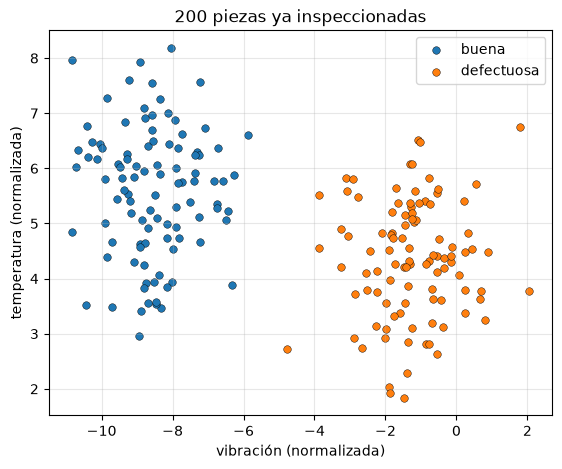

In [3]:
X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.15, random_state=7)

plt.figure(figsize=(6.5, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], s=30, label="buena", edgecolor="k", linewidth=0.3)
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=30, label="defectuosa", edgecolor="k", linewidth=0.3)
plt.xlabel("vibración (normalizada)")
plt.ylabel("temperatura (normalizada)")
plt.title("200 piezas ya inspeccionadas")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 2. El problema: hay infinitas rectas que separan

A ojo se ve que una recta separa los dos grupos. Pero **hay infinitas rectas que lo
consiguen**, y no todas son igual de buenas. Dibujemos tres que separan perfectamente
los datos de entrenamiento.

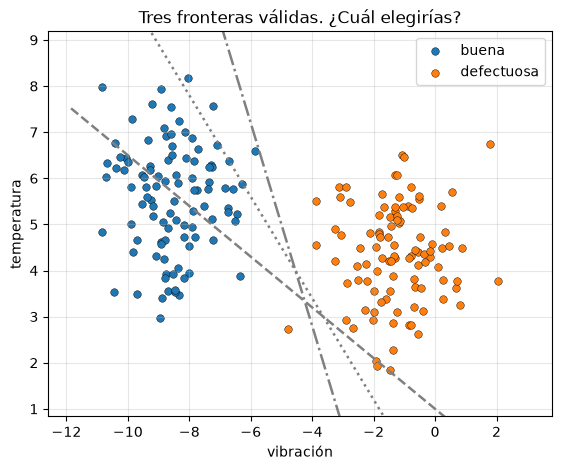

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=30, label="buena", edgecolor="k", linewidth=0.3)
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=30, label="defectuosa", edgecolor="k", linewidth=0.3)

xs = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 10)
for pendiente, corte, estilo in [(-1.1, -1.0, ":"), (-0.55, 1.0, "--"), (-2.2, -6.0, "-.")]:
    ax.plot(xs, pendiente * xs + corte, estilo, lw=1.8, color="grey")

ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
ax.set_xlabel("vibración")
ax.set_ylabel("temperatura")
ax.set_title("Tres fronteras válidas. ¿Cuál elegirías?")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Las tres aciertan el 100 % en los datos que ya tenemos. Pero una pieza nueva que caiga
cerca del borde puede clasificarse distinto según la recta que hayamos elegido.

**La intuición de la SVM:** la mejor frontera es la que deja el **pasillo más ancho**
entre las dos clases. Cuanto más ancho el pasillo, más margen de seguridad ante una
pieza nueva que se salga un poco de lo visto.

## 3. La idea en una frase

**De todas las rectas que separan, quédate con la que está lo más lejos posible de los
puntos de ambos bandos.**

A ese pasillo se le llama **margen**, y a los puntos que lo tocan, **vectores de
soporte** (*support vectors*) — de ahí el nombre del método. Lo llamativo: el resto de
puntos no influyen para nada en la frontera. Podrías borrarlos y saldría la misma recta.

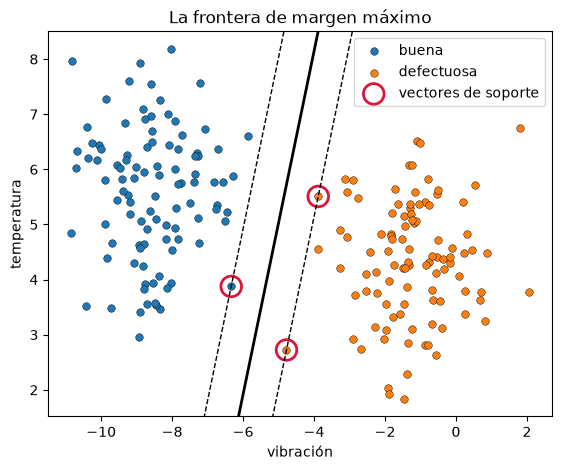

Puntos usados para definir la frontera: 3 de 200


In [5]:
svm_lineal = SVC(kernel="linear", C=1000)  # C alto = no tolerar errores
svm_lineal.fit(X, y)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=30, label="buena", edgecolor="k", linewidth=0.3)
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=30, label="defectuosa", edgecolor="k", linewidth=0.3)

# malla para dibujar la frontera y los bordes del margen
xx, yy = np.meshgrid(
    np.linspace(*ax.get_xlim(), 300),
    np.linspace(*ax.get_ylim(), 300),
)
Z = svm_lineal.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"], linewidths=[1, 2, 1])

ax.scatter(
    svm_lineal.support_vectors_[:, 0], svm_lineal.support_vectors_[:, 1],
    s=220, facecolors="none", edgecolors="crimson", linewidths=2, label="vectores de soporte",
)
ax.set_xlabel("vibración")
ax.set_ylabel("temperatura")
ax.set_title("La frontera de margen máximo")
ax.legend()
plt.show()

print(f"Puntos usados para definir la frontera: {len(svm_lineal.support_vectors_)} de {len(X)}")

Tres puntos de doscientos. Toda la decisión de la fábrica descansa sobre las piezas
**más ambiguas**, las que están justo en la frontera entre buena y defectuosa. Tiene
sentido: son las únicas informativas sobre dónde está el límite.

## 4. Ahora el caso difícil: cuando ninguna recta vale

Cambiamos de línea de producción. Aquí las piezas defectuosas aparecen en dos
regímenes distintos —vibración baja con temperatura alta, y al revés— y el dibujo sale
con forma de dos medias lunas engarzadas.

**Ninguna recta separa esto.** Ninguna.

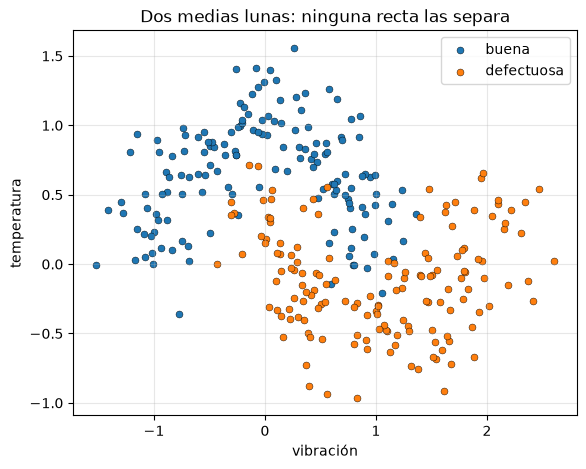

In [6]:
Xm, ym = make_moons(n_samples=300, noise=0.22, random_state=42)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    Xm, ym, test_size=0.3, random_state=42, stratify=ym
)

plt.figure(figsize=(6.5, 5))
plt.scatter(Xm[ym == 0, 0], Xm[ym == 0, 1], s=25, label="buena", edgecolor="k", linewidth=0.3)
plt.scatter(Xm[ym == 1, 0], Xm[ym == 1, 1], s=25, label="defectuosa", edgecolor="k", linewidth=0.3)
plt.xlabel("vibración")
plt.ylabel("temperatura")
plt.title("Dos medias lunas: ninguna recta las separa")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. El truco del kernel

La solución evidente sería inventar variables nuevas: además de `x₁` y `x₂`, añadir
`x₁²`, `x₂²`, `x₁·x₂`... En ese espacio ampliado, lo que era una curva se convierte en
un plano, y ya podemos usar la recta de antes.

El problema es que ese espacio crece muchísimo, y calcular todas esas coordenadas es
caro. **El truco del kernel** es la observación de que la SVM solo necesita saber
*cuán parecidos son dos puntos entre sí*, no sus coordenadas en el espacio ampliado.
Y ese parecido se calcula con una fórmula directa, sin construir el espacio nunca.

El kernel más usado es el **RBF** (base radial): dos puntos se parecen tanto como
cerca estén, con la cercanía decayendo como una campana de Gauss.

Comparemos la SVM lineal con la SVM con kernel RBF sobre las medias lunas.

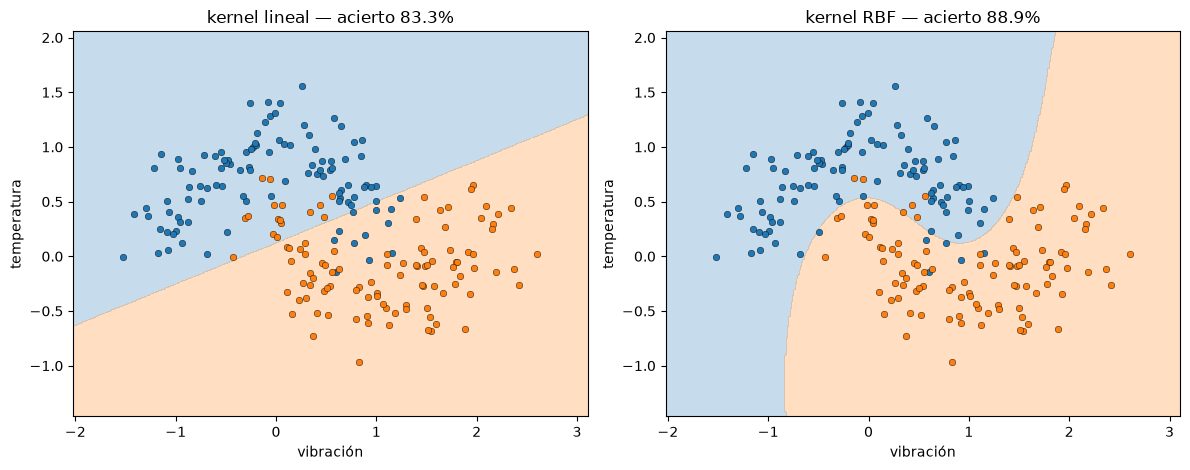

In [7]:
def dibujar_frontera(modelo, X, y, ax, titulo):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, levels=1, colors=["tab:blue", "tab:orange"])
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=22, edgecolor="k", linewidth=0.3)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=22, edgecolor="k", linewidth=0.3)
    ax.set_title(titulo)
    ax.set_xlabel("vibración")
    ax.set_ylabel("temperatura")


svm_l = SVC(kernel="linear").fit(Xm_train, ym_train)
svm_rbf = SVC(kernel="rbf", gamma="scale", C=1.0).fit(Xm_train, ym_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
dibujar_frontera(svm_l, Xm_train, ym_train, axes[0],
                 f"kernel lineal — acierto {svm_l.score(Xm_test, ym_test):.1%}")
dibujar_frontera(svm_rbf, Xm_train, ym_train, axes[1],
                 f"kernel RBF — acierto {svm_rbf.score(Xm_test, ym_test):.1%}")
plt.tight_layout()
plt.show()

La lineal hace lo que puede: parte el plano en dos y se come todos los puntos que
quedan del lado equivocado. La RBF dibuja la curva que hacía falta —**sin que nadie le
haya dicho que la frontera era curva**— y sube el acierto de forma notable.

Y no ha calculado ni una sola coordenada del espacio ampliado.

## 6. El mando que hay que saber tocar: C y gamma

El kernel RBF trae dos parámetros, y entenderlos es la mitad del trabajo:

- **`C`** — cuánto castigas los errores de clasificación. `C` bajo: acepta equivocarte
  en algunos puntos a cambio de una frontera suave. `C` alto: no toleres ni un fallo,
  aunque la frontera salga retorcida.
- **`gamma`** — el alcance de cada punto. `gamma` bajo: cada punto influye lejos, la
  frontera sale suave. `gamma` alto: cada punto solo influye en su vecindad inmediata,
  y la frontera se fragmenta en islas alrededor de cada ejemplo.

`gamma` demasiado alto es la receta clásica del **sobreajuste**: el modelo memoriza el
entrenamiento y falla en datos nuevos. Veámoslo.

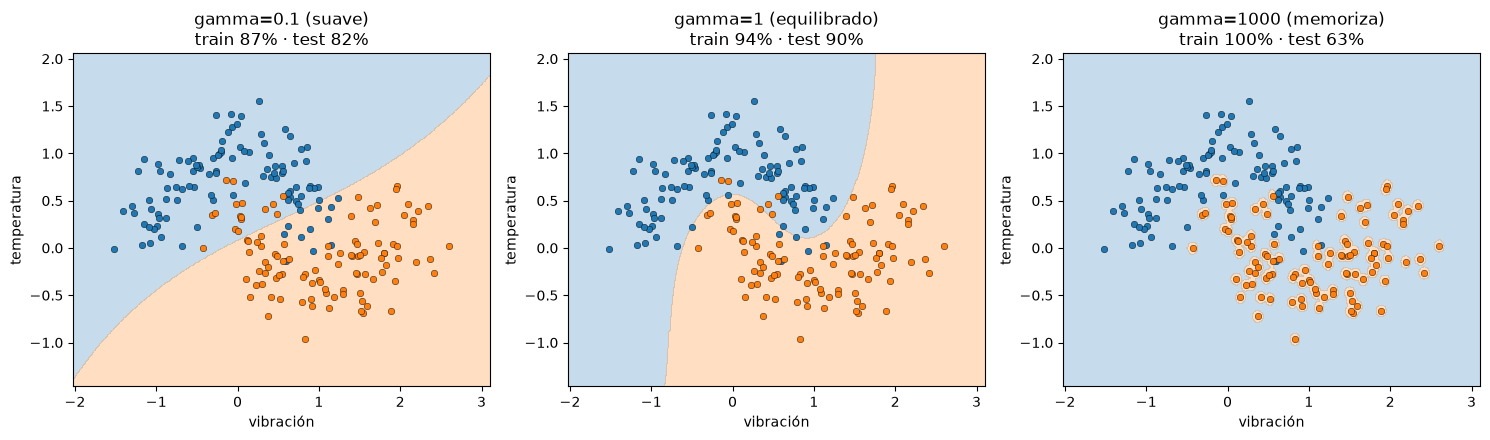

In [8]:
configuraciones = [
    ("gamma=0.1 (suave)", SVC(kernel="rbf", gamma=0.1, C=1.0)),
    ("gamma=1 (equilibrado)", SVC(kernel="rbf", gamma=1.0, C=1.0)),
    ("gamma=1000 (memoriza)", SVC(kernel="rbf", gamma=1000.0, C=1.0)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nombre, modelo) in zip(axes, configuraciones):
    modelo.fit(Xm_train, ym_train)
    train_acc = modelo.score(Xm_train, ym_train)
    test_acc = modelo.score(Xm_test, ym_test)
    dibujar_frontera(modelo, Xm_train, ym_train, ax,
                     f"{nombre}\ntrain {train_acc:.0%} · test {test_acc:.0%}")
plt.tight_layout()
plt.show()

Mira el tercer panel: **100 % de acierto en entrenamiento** y una frontera que es un
archipiélago de islitas alrededor de cada punto. En test cae por debajo del 65 %, peor
que la SVM lineal. Es el retrato perfecto del sobreajuste: el modelo no ha aprendido la
regla, se ha aprendido la lista.

Fíjate en que el panel del medio, con menos acierto en entrenamiento, es el que mejor
generaliza. **Un entrenamiento perfecto es casi siempre una mala señal.**

## 7. ¿Y esto es mejor que una regresión logística?

Comparémoslas en igualdad de condiciones sobre las medias lunas.

In [9]:
comparacion = {
    "Regresión logística": LogisticRegression(),
    "SVM lineal": SVC(kernel="linear"),
    "SVM con kernel RBF": SVC(kernel="rbf", gamma="scale"),
}

for nombre, modelo in comparacion.items():
    modelo.fit(Xm_train, ym_train)
    print(f"{nombre:22} acierto en test: {modelo.score(Xm_test, ym_test):.1%}")

Regresión logística    acierto en test: 83.3%


SVM lineal             acierto en test: 83.3%
SVM con kernel RBF     acierto en test: 88.9%


Las dos lineales empatan porque están limitadas por lo mismo: solo saben trazar
rectas. La diferencia no la hace el algoritmo, la hace **el kernel**.

## 8. Cuándo usarlo y cuándo no

**Úsalo cuando:**

- Tienes **pocos datos** (de cientos a decenas de miles) y muchas variables. Las SVM
  son notablemente robustas en ese régimen, donde una red neuronal se sobreajusta.
- La frontera es claramente curva pero no sabes de qué forma.

**No lo uses cuando:**

- Tienes cientos de miles de filas: el coste crece más o menos con el **cuadrado** del
  número de muestras, y se vuelve impracticable.
- Necesitas explicar la decisión: la frontera vive en un espacio que nunca se
  construye, así que no hay coeficientes que enseñar. Para eso,
  [árboles](05_04_arbol_de_decision.py) o [regresión logística](05_01_regresion_lineal_y_logistica.py).
- Necesitas probabilidades calibradas: una SVM da un lado de la frontera, no un
  "73 % de confianza".

**El apunte histórico:** entre 1995 y 2012 esto era el estado del arte. Lo que cambió
no fue que las SVM empeorasen, sino que aparecieron datasets con millones de ejemplos
— justo donde las SVM no llegan y las redes profundas brillan.

## 9. Prueba tú

1. Sube el ruido de `make_moons` a `noise=0.4`. ¿Cuánto acierto pierde la RBF? ¿Y la lineal?
2. Prueba `C=0.01` con `gamma=1`. ¿Qué le pasa a la frontera cuando dejas de castigar
   los errores?
2-bis. Prueba `gamma=100` (en vez de 1000). Verás que **todavía generaliza bien**: el
   sobreajuste no aparece de golpe en un valor mágico, sino que se agrava poco a poco.
   Localizar dónde empieza a doler es exactamente para lo que sirve la validación cruzada.
3. Cambia `kernel="poly", degree=3`. ¿Se parece más a la lineal o a la RBF?
4. Con el primer dataset (`make_blobs`), mueve un único punto de una clase al centro
   de la otra y vuelve a entrenar. ¿Cuántos vectores de soporte aparecen ahora?